# Are the Steelers Really Clutch?

Two-part analysis (2020–2025 regular seasons):
1. **One-score record** — W-L in games decided by ≤8 points, ranked league-wide
2. **Heart attack rate** — % of wins where PIT held a 14+ point lead in the 2nd half but won by ≤8

In [1]:
import nfl_data_py as nfl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

SEASONS = [2020, 2021, 2022, 2023, 2024, 2025]

BG     = "#0a0a0a"
FG     = "#e5e5e5"
ACCENT = "#f97316"   # orange — highlight
DIM    = "#374151"   # muted bars
RED    = "#ef4444"
CYAN   = "#22d3ee"

OUT = r"C:\Users\Arjun\Documents\NFL_Tempo\public\images\steelers-clutch"
os.makedirs(OUT, exist_ok=True)
print("Output dir:", OUT)

Output dir: C:\Users\Arjun\Documents\NFL_Tempo\public\images\steelers-clutch


## Part 1 — One-Score Game Record (2020–2025)

Load regular-season schedules, compute margin, flag one-score games (≤8 points).

In [2]:
schedules = nfl.import_schedules(SEASONS)
reg = schedules[schedules['game_type'] == 'REG'].copy()

# Drop games without final scores (future games)
reg = reg.dropna(subset=['home_score', 'away_score'])
reg['margin'] = (reg['home_score'] - reg['away_score']).abs()
reg['one_score'] = reg['margin'] <= 8

print(f"Regular season games 2020–2025: {len(reg):,}")
print(f"One-score games: {reg['one_score'].sum():,} ({reg['one_score'].mean()*100:.1f}%)")
reg[['season','week','home_team','away_team','home_score','away_score','margin','one_score']].head()

Regular season games 2020–2025: 1,615
One-score games: 863 (53.4%)


,season,week,home_team,away_team,home_score,away_score,margin,one_score
5583,2020,1,KC,HOU,34.000,20.000,14.000,False
5584,2020,1,ATL,SEA,25.000,38.000,13.000,False
5585,2020,1,BAL,CLE,38.000,6.000,32.000,False
5586,2020,1,BUF,NYJ,27.000,17.000,10.000,False
5587,2020,1,CAR,LV,30.000,34.000,4.000,True


In [3]:
# Build team-game rows: one row per team per game
home_rows = reg[['game_id','season','home_team','away_team','home_score','away_score','margin','one_score']].copy()
home_rows.columns = ['game_id','season','team','opponent','team_score','opp_score','margin','one_score']
home_rows['win'] = home_rows['team_score'] > home_rows['opp_score']

away_rows = reg[['game_id','season','away_team','home_team','away_score','home_score','margin','one_score']].copy()
away_rows.columns = ['game_id','season','team','opponent','team_score','opp_score','margin','one_score']
away_rows['win'] = away_rows['team_score'] > away_rows['opp_score']

games = pd.concat([home_rows, away_rows], ignore_index=True)
one_score_games = games[games['one_score']]

print(f"Team-game rows: {len(games):,}")
print(f"One-score team-game rows: {len(one_score_games):,}")

Team-game rows: 3,230
One-score team-game rows: 1,726


In [4]:
# W-L record in one-score games, all teams
one_score_record = (
    one_score_games
    .groupby('team')
    .agg(
        games=('win', 'count'),
        wins=('win', 'sum')
    )
    .assign(losses=lambda d: d['games'] - d['wins'])
    .assign(win_pct=lambda d: d['wins'] / d['games'])
    .sort_values('win_pct', ascending=False)
    .reset_index()
)

one_score_record['rank'] = range(1, len(one_score_record) + 1)
print("One-score game record (2020–2025):")
print(one_score_record.to_string(index=False))

One-score game record (2020–2025):
team  games  wins  losses  win_pct  rank
 PIT     63    44      19    0.698     1
  KC     59    38      21    0.644     2
 PHI     56    36      20    0.643     3
 MIN     68    43      25    0.632     4
 SEA     56    33      23    0.589     5
 DAL     46    26      20    0.565     6
 BUF     48    27      21    0.562     7
  TB     49    27      22    0.551     8
  LA     53    29      24    0.547     9
 MIA     47    25      22    0.532    10
  GB     55    29      26    0.527    11
 CLE     52    26      26    0.500    12
 LAC     61    30      31    0.492    13
 IND     57    28      29    0.491    14
 TEN     55    27      28    0.491    15
 WAS     55    27      28    0.491    16
 DET     51    25      26    0.490    17
  SF     40    19      21    0.475    18
  LV     55    26      29    0.473    19
 BAL     54    25      29    0.463    20
  NE     52    24      28    0.462    21
 ATL     64    29      35    0.453    22
 DEN     58    26     

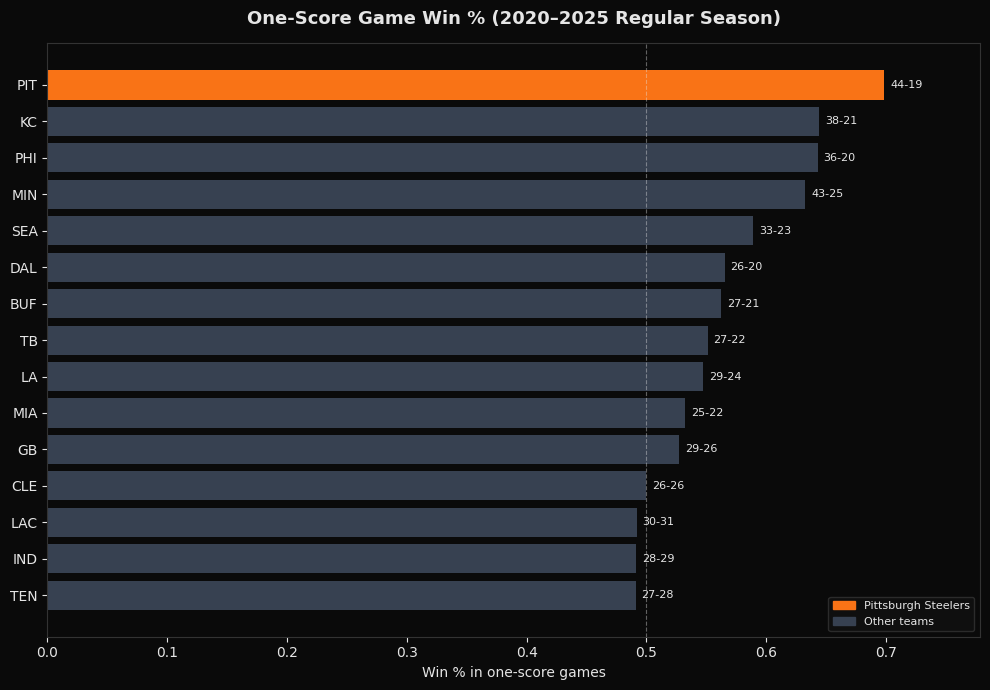

Saved one-score-record.png


In [5]:
# Chart: Top 15 teams by one-score win% (highlight PIT)
top15 = one_score_record.head(15)
colors = [ACCENT if t == 'PIT' else DIM for t in top15['team']]

fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
ax.set_facecolor(BG)

bars = ax.barh(top15['team'][::-1], top15['win_pct'][::-1], color=colors[::-1])

# Label each bar with W-L
for i, (_, row) in enumerate(top15[::-1].iterrows()):
    ax.text(
        row['win_pct'] + 0.005,
        i,
        f"{int(row['wins'])}-{int(row['losses'])}",
        va='center', color=FG, fontsize=8
    )

ax.axvline(0.5, color=FG, linewidth=0.8, linestyle='--', alpha=0.4)
ax.set_xlabel("Win % in one-score games", color=FG, fontsize=10)
ax.set_title("One-Score Game Win % (2020–2025 Regular Season)", color=FG, fontsize=13, fontweight='bold', pad=14)
ax.tick_params(colors=FG)
for spine in ax.spines.values():
    spine.set_edgecolor("#333333")
ax.set_xlim(0, top15['win_pct'].max() + 0.08)

pit_patch = mpatches.Patch(color=ACCENT, label='Pittsburgh Steelers')
other_patch = mpatches.Patch(color=DIM, label='Other teams')
ax.legend(handles=[pit_patch, other_patch], facecolor='#111111', edgecolor='#333333', labelcolor=FG, fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'one-score-record.png'), dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Saved one-score-record.png")

## Part 2 — Heart Attack Rate

For each game, use play-by-play to find the **maximum lead** a team held **in the 2nd half**.

**Heart attack win** = team won AND held a 14+ point lead in the 2nd half AND final margin ≤ 8.

In [6]:
print("Loading play-by-play for 2020–2025 (this takes a minute)...")
pbp = nfl.import_pbp_data(SEASONS)
pbp_reg = pbp[pbp['season_type'] == 'REG'].copy()
print(f"PBP plays loaded: {len(pbp_reg):,}")

Loading play-by-play for 2020–2025 (this takes a minute)...


2020 done.


2021 done.


2022 done.


2023 done.


2024 done.


2025 done.
Downcasting floats.


PBP plays loaded: 281,339


In [7]:
# score_differential = posteam_score - defteam_score (from posteam perspective)
# We want: for each team in each game, what was their max lead in the 2nd half?
# A team's lead = their score - opponent's score.
# In PBP: when team is posteam, their lead = score_differential
#          when team is defteam, their lead = -score_differential

# Filter to 2nd half plays (game_half == 'Half2' or quarter >= 3)
second_half = pbp_reg[
    (pbp_reg['qtr'] >= 3) &
    (pbp_reg['score_differential'].notna()) &
    (pbp_reg['posteam'].notna()) &
    (pbp_reg['defteam'].notna())
].copy()

print(f"2nd half plays: {len(second_half):,}")

2nd half plays: 134,635


In [8]:
# From posteam perspective: their lead = score_differential
# From defteam perspective: their lead = -score_differential

as_offense = second_half[['game_id', 'posteam', 'score_differential']].copy()
as_offense.columns = ['game_id', 'team', 'lead']

as_defense = second_half[['game_id', 'defteam', 'score_differential']].copy()
as_defense['lead'] = -as_defense['score_differential']
as_defense = as_defense[['game_id', 'defteam', 'lead']]
as_defense.columns = ['game_id', 'team', 'lead']

all_leads = pd.concat([as_offense, as_defense], ignore_index=True)

# Max lead per team per game in 2nd half
max_leads = (
    all_leads
    .groupby(['game_id', 'team'])['lead']
    .max()
    .reset_index()
    .rename(columns={'lead': 'max_2h_lead'})
)

print(f"Team-game lead rows: {len(max_leads):,}")
max_leads[max_leads['team'] == 'PIT'].head(10)

Team-game lead rows: 3,230


,game_id,team,max_2h_lead
25,2020_01_PIT_NYG,PIT,16.000
43,2020_02_DEN_PIT,PIT,14.000
77,2020_03_HOU_PIT,PIT,7.000
151,2020_05_PHI_PIT,PIT,17.000
165,2020_06_CLE_PIT,PIT,31.000
202,2020_07_PIT_TEN,PIT,20.000
231,2020_08_PIT_BAL,PIT,4.000
263,2020_09_PIT_DAL,PIT,5.000
271,2020_10_CIN_PIT,PIT,29.000
319,2020_11_PIT_JAX,PIT,24.000


In [9]:
# Merge max leads back onto the games table
games_with_leads = games.merge(max_leads, on=['game_id', 'team'], how='left')

# Heart attack win: won AND max 2nd-half lead >= 14 AND final margin <= 8
games_with_leads['heart_attack_win'] = (
    (games_with_leads['win'] == True) &
    (games_with_leads['max_2h_lead'] >= 14) &
    (games_with_leads['margin'] <= 8)
)

# Also flag any game where they held a 14+ lead in 2H (wins and losses)
games_with_leads['had_big_lead'] = games_with_leads['max_2h_lead'] >= 14

print("Heart attack wins by PIT:")
pit = games_with_leads[games_with_leads['team'] == 'PIT']
print(f"  Total wins: {pit['win'].sum()}")
print(f"  Heart attack wins: {pit['heart_attack_win'].sum()}")
print(f"  Games with 14+ lead in 2H: {pit['had_big_lead'].sum()}")

Heart attack wins by PIT:
  Total wins: 60
  Heart attack wins: 11
  Games with 14+ lead in 2H: 24


In [10]:
# Per-team heart attack stats
ha_stats = (
    games_with_leads
    .groupby('team')
    .agg(
        total_wins=('win', 'sum'),
        heart_attack_wins=('heart_attack_win', 'sum'),
        games_with_big_lead=('had_big_lead', 'sum'),
    )
    .reset_index()
)

# Rate: heart attack wins as % of all wins
ha_stats['ha_rate_of_wins'] = ha_stats['heart_attack_wins'] / ha_stats['total_wins']

# Rate: of games where they had a big lead, how often did it turn into a heart attack win?
ha_stats['ha_rate_of_big_leads'] = ha_stats['heart_attack_wins'] / ha_stats['games_with_big_lead'].replace(0, np.nan)

ha_stats = ha_stats.sort_values('heart_attack_wins', ascending=False).reset_index(drop=True)
ha_stats['rank'] = range(1, len(ha_stats) + 1)

print("Heart attack stats (2020–2025):")
print(ha_stats.to_string(index=False))

Heart attack stats (2020–2025):
team  total_wins  heart_attack_wins  games_with_big_lead  ha_rate_of_wins  ha_rate_of_big_leads  rank
 PHI          63                 12                   39            0.190                 0.308     1
 PIT          60                 11                   24            0.183                 0.458     2
 TEN          42                 11                   24            0.262                 0.458     3
  LA          59                 10                   37            0.169                 0.270     4
 MIN          58                 10                   24            0.172                 0.417     5
 SEA          61                 10                   33            0.164                 0.303     6
 ATL          41                  9                   23            0.220                 0.391     7
 BAL          62                  8                   44            0.129                 0.182     8
  SF          59                  8               

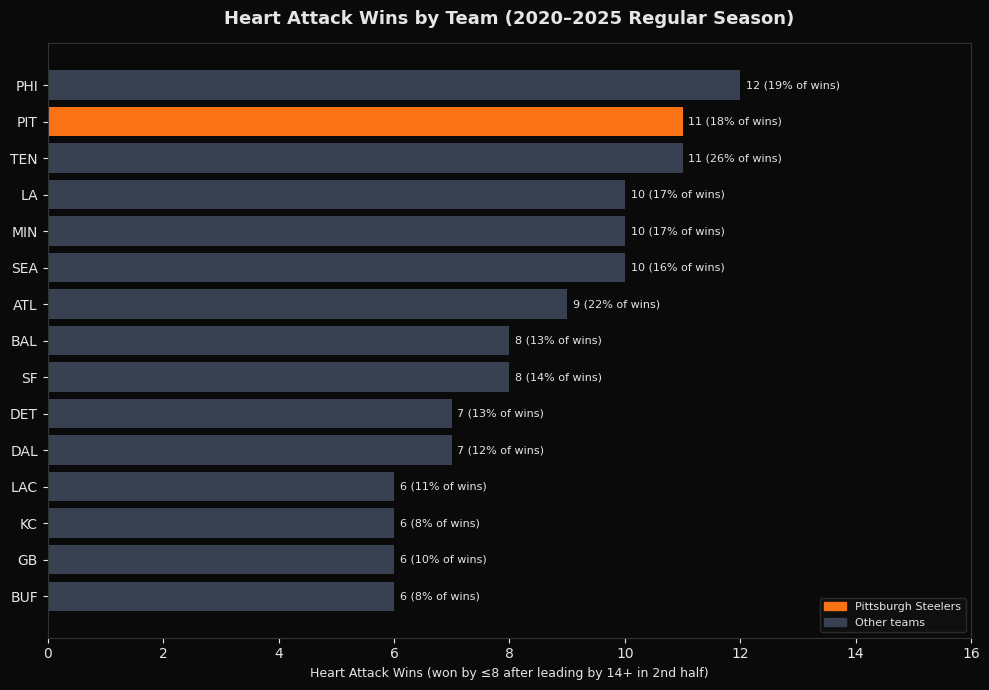

Saved heart-attack-wins.png


In [11]:
# Chart: Heart attack wins — top 15 teams by raw count (highlight PIT)
top15_ha = ha_stats.head(15)
colors_ha = [ACCENT if t == 'PIT' else DIM for t in top15_ha['team']]

fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
ax.set_facecolor(BG)

ax.barh(top15_ha['team'][::-1], top15_ha['heart_attack_wins'][::-1], color=colors_ha[::-1])

for i, (_, row) in enumerate(top15_ha[::-1].iterrows()):
    ax.text(
        row['heart_attack_wins'] + 0.1,
        i,
        f"{int(row['heart_attack_wins'])} ({row['ha_rate_of_wins']*100:.0f}% of wins)",
        va='center', color=FG, fontsize=8
    )

ax.set_xlabel("Heart Attack Wins (won by ≤8 after leading by 14+ in 2nd half)", color=FG, fontsize=9)
ax.set_title("Heart Attack Wins by Team (2020–2025 Regular Season)", color=FG, fontsize=13, fontweight='bold', pad=14)
ax.tick_params(colors=FG)
for spine in ax.spines.values():
    spine.set_edgecolor("#333333")
ax.set_xlim(0, top15_ha['heart_attack_wins'].max() + 4)

pit_patch = mpatches.Patch(color=ACCENT, label='Pittsburgh Steelers')
other_patch = mpatches.Patch(color=DIM, label='Other teams')
ax.legend(handles=[pit_patch, other_patch], facecolor='#111111', edgecolor='#333333', labelcolor=FG, fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'heart-attack-wins.png'), dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Saved heart-attack-wins.png")

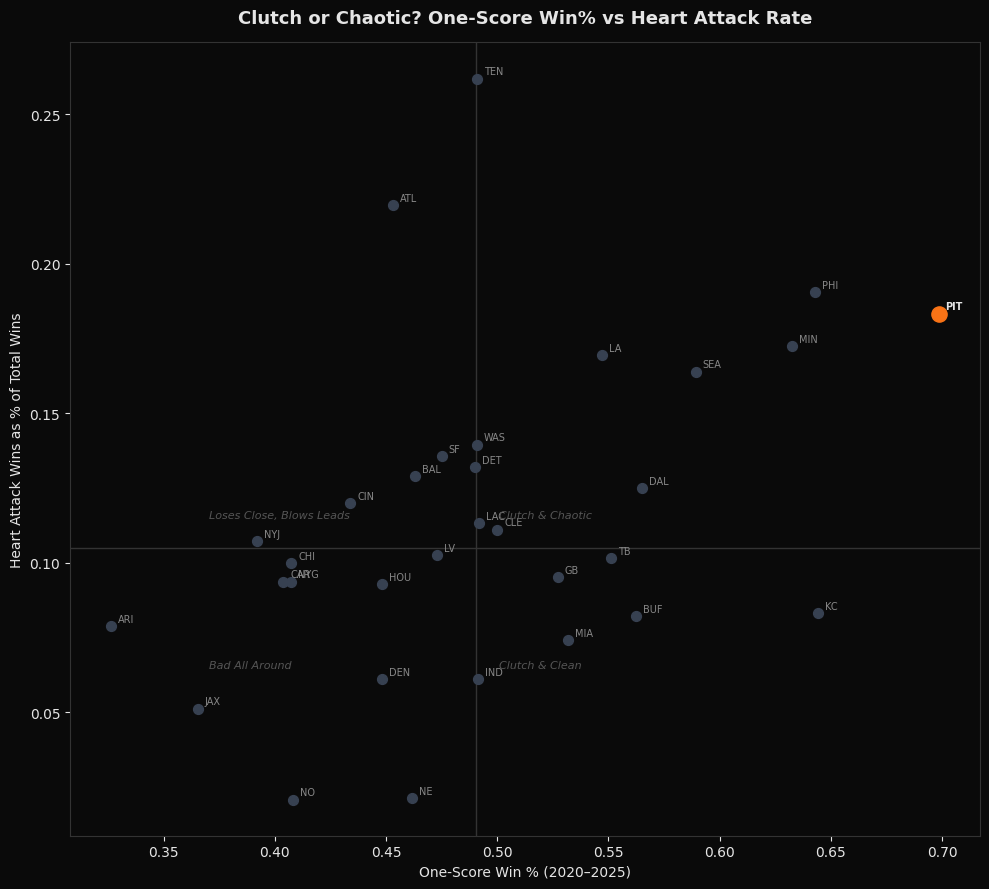

Saved clutch-vs-chaotic.png


In [12]:
# Chart: Scatter — one-score win% (x) vs heart attack rate of wins (y)
# Quadrant: high one-score win% + high HA rate = the Steelers archetype
scatter_df = one_score_record[['team', 'win_pct']].merge(
    ha_stats[['team', 'ha_rate_of_wins', 'heart_attack_wins']],
    on='team'
)

fig, ax = plt.subplots(figsize=(10, 9), facecolor=BG)
ax.set_facecolor(BG)

med_x = scatter_df['win_pct'].median()
med_y = scatter_df['ha_rate_of_wins'].median()
ax.axvline(med_x, color='#333333', linewidth=1)
ax.axhline(med_y, color='#333333', linewidth=1)

for _, row in scatter_df.iterrows():
    color = ACCENT if row['team'] == 'PIT' else DIM
    size = 120 if row['team'] == 'PIT' else 50
    ax.scatter(row['win_pct'], row['ha_rate_of_wins'], color=color, s=size, zorder=3)
    ax.annotate(
        row['team'],
        (row['win_pct'], row['ha_rate_of_wins']),
        textcoords='offset points', xytext=(5, 3),
        color=FG if row['team'] == 'PIT' else '#888888',
        fontsize=7,
        fontweight='bold' if row['team'] == 'PIT' else 'normal'
    )

# Quadrant labels
ax.text(med_x + 0.01, med_y + 0.01, "Clutch & Chaotic", color='#555555', fontsize=8, fontstyle='italic')
ax.text(med_x - 0.12, med_y + 0.01, "Loses Close, Blows Leads", color='#555555', fontsize=8, fontstyle='italic')
ax.text(med_x + 0.01, med_y - 0.04, "Clutch & Clean", color='#555555', fontsize=8, fontstyle='italic')
ax.text(med_x - 0.12, med_y - 0.04, "Bad All Around", color='#555555', fontsize=8, fontstyle='italic')

ax.set_xlabel("One-Score Win % (2020–2025)", color=FG, fontsize=10)
ax.set_ylabel("Heart Attack Wins as % of Total Wins", color=FG, fontsize=10)
ax.set_title("Clutch or Chaotic? One-Score Win% vs Heart Attack Rate", color=FG, fontsize=13, fontweight='bold', pad=14)
ax.tick_params(colors=FG)
for spine in ax.spines.values():
    spine.set_edgecolor("#333333")

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'clutch-vs-chaotic.png'), dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Saved clutch-vs-chaotic.png")

In [13]:
# Print PIT-specific game log of heart attack wins for article anecdotes
pit_ha_wins = games_with_leads[
    (games_with_leads['team'] == 'PIT') &
    (games_with_leads['heart_attack_win'] == True)
].merge(
    reg[['game_id','week','home_team','away_team']],
    on='game_id'
).sort_values(['season','week'])

print("Steelers heart attack wins (2020–2025):")
print(pit_ha_wins[['season','week','home_team','away_team','team_score','opp_score','margin','max_2h_lead']].to_string(index=False))

Steelers heart attack wins (2020–2025):
 season  week home_team away_team  team_score  opp_score  margin  max_2h_lead
   2020     2       PIT       DEN      26.000     21.000   5.000       14.000
   2020     7       TEN       PIT      27.000     24.000   3.000       20.000
   2021     5       PIT       DEN      27.000     19.000   8.000       18.000
   2021     6       PIT       SEA      23.000     20.000   3.000       14.000
   2021     9       PIT       CHI      29.000     27.000   2.000       14.000
   2022    15       CAR       PIT      24.000     16.000   8.000       14.000
   2023     3        LV       PIT      23.000     18.000   5.000       16.000
   2024     8       PIT       NYG      26.000     18.000   8.000       14.000
   2024    13       CIN       PIT      44.000     38.000   6.000       17.000
   2025     4       PIT       MIN      24.000     21.000   3.000       18.000
   2025     9       PIT       IND      27.000     20.000   7.000       17.000


In [14]:
# Summary stats for the article
pit_one_score = one_score_record[one_score_record['team'] == 'PIT'].iloc[0]
pit_ha = ha_stats[ha_stats['team'] == 'PIT'].iloc[0]

print("=== STEELERS SUMMARY (2020–2025) ===")
print(f"One-score record: {int(pit_one_score['wins'])}-{int(pit_one_score['losses'])} ({pit_one_score['win_pct']*100:.1f}%)")
print(f"Rank in one-score win%: #{int(pit_one_score['rank'])} in the NFL")
print(f"Total wins: {int(pit_ha['total_wins'])}")
print(f"Heart attack wins: {int(pit_ha['heart_attack_wins'])} ({pit_ha['ha_rate_of_wins']*100:.1f}% of all wins)")
print(f"Heart attack rank (raw count): #{int(pit_ha['rank'])} in the NFL")
print(f"Games with 14+ 2H lead: {int(pit_ha['games_with_big_lead'])}")
print(f"Heart attack rate among big-lead games: {pit_ha['ha_rate_of_big_leads']*100:.1f}%")

=== STEELERS SUMMARY (2020–2025) ===
One-score record: 44-19 (69.8%)
Rank in one-score win%: #1 in the NFL
Total wins: 60
Heart attack wins: 11 (18.3% of all wins)
Heart attack rank (raw count): #2 in the NFL
Games with 14+ 2H lead: 24
Heart attack rate among big-lead games: 45.8%


## Part 3 — Comeback Wins\n\nSymmetric with the heart attack analysis: a **comeback win** = team was trailing by 14+ points at some point in the 2nd half AND won. Keeps the threshold consistent so the two metrics are directly comparable.

In [15]:
# Min lead (most they were trailing) per team per game in 2nd half
min_leads = (
    all_leads
    .groupby(['game_id', 'team'])['lead']
    .min()
    .reset_index()
    .rename(columns={'lead': 'min_2h_lead'})
)

# Merge onto games
games_with_leads2 = games_with_leads.merge(min_leads, on=['game_id', 'team'], how='left')

# Comeback win: won AND were trailing by 14+ in the 2nd half
games_with_leads2['comeback_win'] = (
    (games_with_leads2['win'] == True) &
    (games_with_leads2['min_2h_lead'] <= -14)
)

games_with_leads2['had_big_deficit'] = games_with_leads2['min_2h_lead'] <= -14

print("Comeback wins by PIT:")
pit2 = games_with_leads2[games_with_leads2['team'] == 'PIT']
print(f"  Total wins: {pit2['win'].sum()}")
print(f"  Comeback wins (trailed by 14+ in 2H): {pit2['comeback_win'].sum()}")
print(f"  Games where they trailed by 14+: {pit2['had_big_deficit'].sum()}")

Comeback wins by PIT:
  Total wins: 60
  Comeback wins (trailed by 14+ in 2H): 1
  Games where they trailed by 14+: 26


In [16]:
# Per-team comeback stats
cb_stats = (
    games_with_leads2
    .groupby('team')
    .agg(
        total_wins=('win', 'sum'),
        comeback_wins=('comeback_win', 'sum'),
        games_with_big_deficit=('had_big_deficit', 'sum'),
    )
    .reset_index()
)

cb_stats['cb_rate_of_deficits'] = cb_stats['comeback_wins'] / cb_stats['games_with_big_deficit'].replace(0, np.nan)
cb_stats['cb_rate_of_wins'] = cb_stats['comeback_wins'] / cb_stats['total_wins']
cb_stats = cb_stats.sort_values('comeback_wins', ascending=False).reset_index(drop=True)
cb_stats['cb_rank'] = range(1, len(cb_stats) + 1)

print("Comeback win stats (2020–2025):")
print(cb_stats.to_string(index=False))

Comeback win stats (2020–2025):
team  total_wins  comeback_wins  games_with_big_deficit  cb_rate_of_deficits  cb_rate_of_wins  cb_rank
 DEN          49              4                      27                0.148            0.082        1
 ARI          38              3                      32                0.094            0.079        2
 CIN          50              3                      29                0.103            0.060        3
 BAL          62              3                      14                0.214            0.048        4
 CHI          40              3                      35                0.086            0.075        5
 TEN          42              3                      38                0.079            0.071        6
 DAL          56              2                      30                0.067            0.036        7
 BUF          73              2                      11                0.182            0.027        8
  GB          63              2          

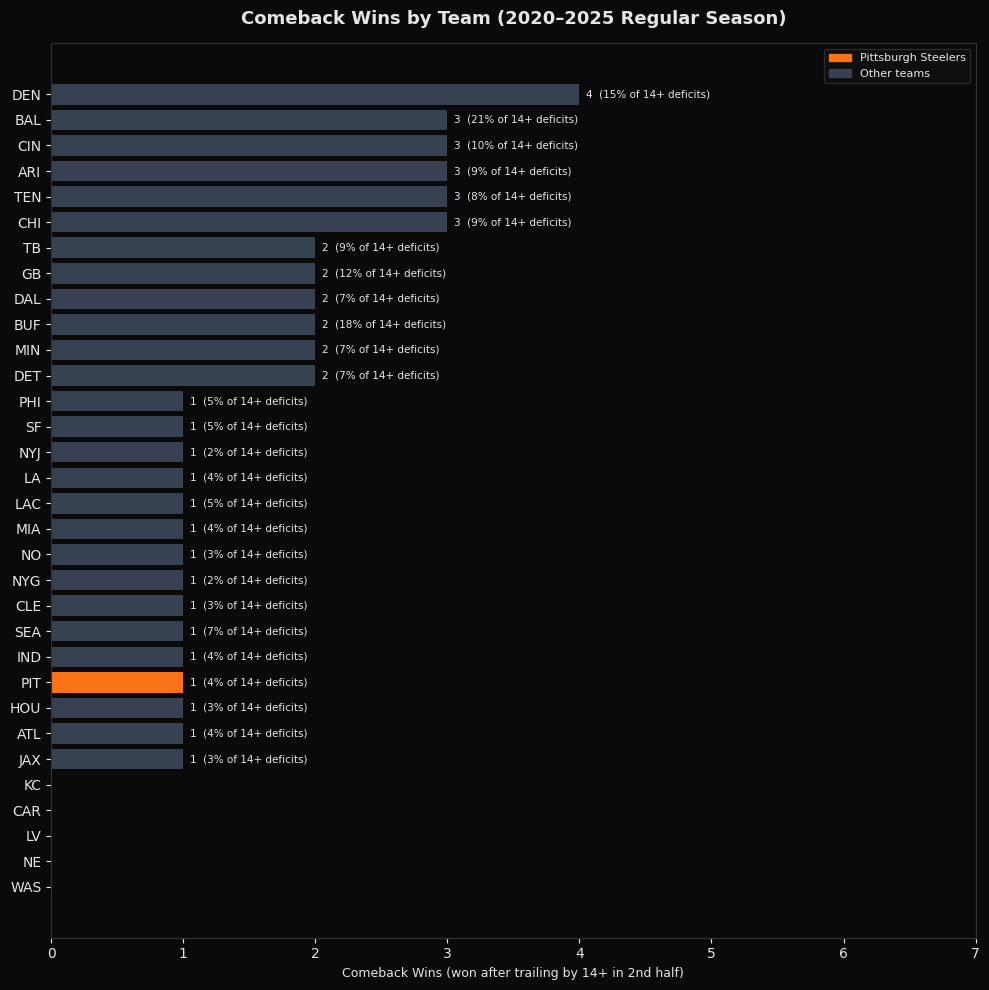

Saved comeback-wins.png


In [17]:
# Chart: Comeback wins — all teams, sorted, highlight PIT
cb_sorted = cb_stats.sort_values('comeback_wins', ascending=True)
colors_cb = [ACCENT if t == 'PIT' else DIM for t in cb_sorted['team']]

fig, ax = plt.subplots(figsize=(10, 10), facecolor=BG)
ax.set_facecolor(BG)
ax.barh(cb_sorted['team'], cb_sorted['comeback_wins'], color=colors_cb)

for i, (_, row) in enumerate(cb_sorted.iterrows()):
    if row['comeback_wins'] > 0:
        ax.text(
            row['comeback_wins'] + 0.05,
            i,
            f"{int(row['comeback_wins'])}  ({row['cb_rate_of_deficits']*100:.0f}% of 14+ deficits)",
            va='center', color=FG, fontsize=7.5
        )

ax.set_xlabel("Comeback Wins (won after trailing by 14+ in 2nd half)", color=FG, fontsize=9)
ax.set_title("Comeback Wins by Team (2020–2025 Regular Season)", color=FG, fontsize=13, fontweight='bold', pad=14)
ax.tick_params(colors=FG)
for spine in ax.spines.values():
    spine.set_edgecolor("#333333")
ax.set_xlim(0, cb_sorted['comeback_wins'].max() + 3)

pit_patch = mpatches.Patch(color=ACCENT, label='Pittsburgh Steelers')
other_patch = mpatches.Patch(color=DIM, label='Other teams')
ax.legend(handles=[pit_patch, other_patch], facecolor='#111111', edgecolor='#333333', labelcolor=FG, fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'comeback-wins.png'), dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Saved comeback-wins.png")

In [18]:
# PIT summary for comeback wins
pit_cb = cb_stats[cb_stats['team'] == 'PIT'].iloc[0]
print("=== STEELERS COMEBACK SUMMARY (2020–2025) ===")
print(f"Games where they trailed by 14+ in 2H: {int(pit_cb['games_with_big_deficit'])}")
print(f"Comeback wins: {int(pit_cb['comeback_wins'])} (rank #{int(pit_cb['cb_rank'])} in NFL)")
print(f"Comeback rate when trailing 14+: {pit_cb['cb_rate_of_deficits']*100:.1f}%")
print(f"Comeback wins as % of total wins: {pit_cb['cb_rate_of_wins']*100:.1f}%")

# Print PIT-specific comeback game log
pit_cb_games = games_with_leads2[
    (games_with_leads2['team'] == 'PIT') &
    (games_with_leads2['comeback_win'] == True)
].merge(
    reg[['game_id','week','home_team','away_team']],
    on='game_id'
).sort_values(['season','week'])

print("\nSteelers comeback wins (2020–2025):")
print(pit_cb_games[['season','week','home_team','away_team','team_score','opp_score','margin','min_2h_lead']].to_string(index=False))

=== STEELERS COMEBACK SUMMARY (2020–2025) ===
Games where they trailed by 14+ in 2H: 26
Comeback wins: 1 (rank #18 in NFL)
Comeback rate when trailing 14+: 3.8%
Comeback wins as % of total wins: 1.7%

Steelers comeback wins (2020–2025):
 season  week home_team away_team  team_score  opp_score  margin  min_2h_lead
   2020    16       PIT       IND      28.000     24.000   4.000      -17.000


## Part 4 — Blown Leads (14+ Lead in 2H → Loss)\n\nThe most damning category: team held a 14+ point lead in the 2nd half and still lost.

In [19]:
# Blown lead: had 14+ point 2H lead AND lost
games_with_leads2['blown_lead'] = (
    (games_with_leads2['win'] == False) &
    (games_with_leads2['max_2h_lead'] >= 14)
)

# Per-team blown lead stats
blown_stats = (
    games_with_leads2
    .groupby('team')
    .agg(
        games_with_big_lead=('had_big_lead', 'sum'),
        heart_attack_wins=('heart_attack_win', 'sum'),
        blown_leads=('blown_lead', 'sum'),
    )
    .reset_index()
)

# Of all games with a 14+ 2H lead: heart attack win + blown lead = total "lead squandered" events
blown_stats['lead_squandered'] = blown_stats['heart_attack_wins'] + blown_stats['blown_leads']
blown_stats['squander_rate'] = blown_stats['lead_squandered'] / blown_stats['games_with_big_lead'].replace(0, np.nan)
blown_stats['blown_rate'] = blown_stats['blown_leads'] / blown_stats['games_with_big_lead'].replace(0, np.nan)

blown_stats = blown_stats.sort_values('blown_leads', ascending=False).reset_index(drop=True)
blown_stats['blown_rank'] = range(1, len(blown_stats) + 1)

print("Blown lead stats (2020–2025):")
print(blown_stats.to_string(index=False))

print("\n=== STEELERS BLOWN LEAD SUMMARY ===")
pit_bl = blown_stats[blown_stats['team'] == 'PIT'].iloc[0]
print(f"Games with 14+ 2H lead: {int(pit_bl['games_with_big_lead'])}")
print(f"Heart attack wins (survived):  {int(pit_bl['heart_attack_wins'])}")
print(f"Blown leads (lost):            {int(pit_bl['blown_leads'])} (rank #{int(pit_bl['blown_rank'])} in NFL)")
print(f"Total lead squandered events:  {int(pit_bl['lead_squandered'])} ({pit_bl['squander_rate']*100:.1f}% of big-lead games)")

Blown lead stats (2020–2025):
team  games_with_big_lead  heart_attack_wins  blown_leads  lead_squandered  squander_rate  blown_rate  blown_rank
 ATL                   23                  9            4               13          0.565       0.174           1
 BAL                   44                  8            3               11          0.250       0.068           2
 IND                   26                  3            3                6          0.231       0.115           3
  LA                   37                 10            3               13          0.351       0.081           4
 PHI                   39                 12            3               15          0.385       0.077           5
 CIN                   33                  6            2                8          0.242       0.061           6
 CHI                   21                  4            2                6          0.286       0.095           7
 ARI                   24                  3            2 

In [20]:
# Print PIT blown lead game log
pit_bl_games = games_with_leads2[
    (games_with_leads2['team'] == 'PIT') &
    (games_with_leads2['blown_lead'] == True)
].merge(
    reg[['game_id','week','home_team','away_team']],
    on='game_id'
).sort_values(['season','week'])

print("Steelers blown leads (2020–2025):")
print(pit_bl_games[['season','week','home_team','away_team','team_score','opp_score','margin','max_2h_lead']].to_string(index=False))

Steelers blown leads (2020–2025):
Empty DataFrame
Columns: [season, week, home_team, away_team, team_score, opp_score, margin, max_2h_lead]
Index: []


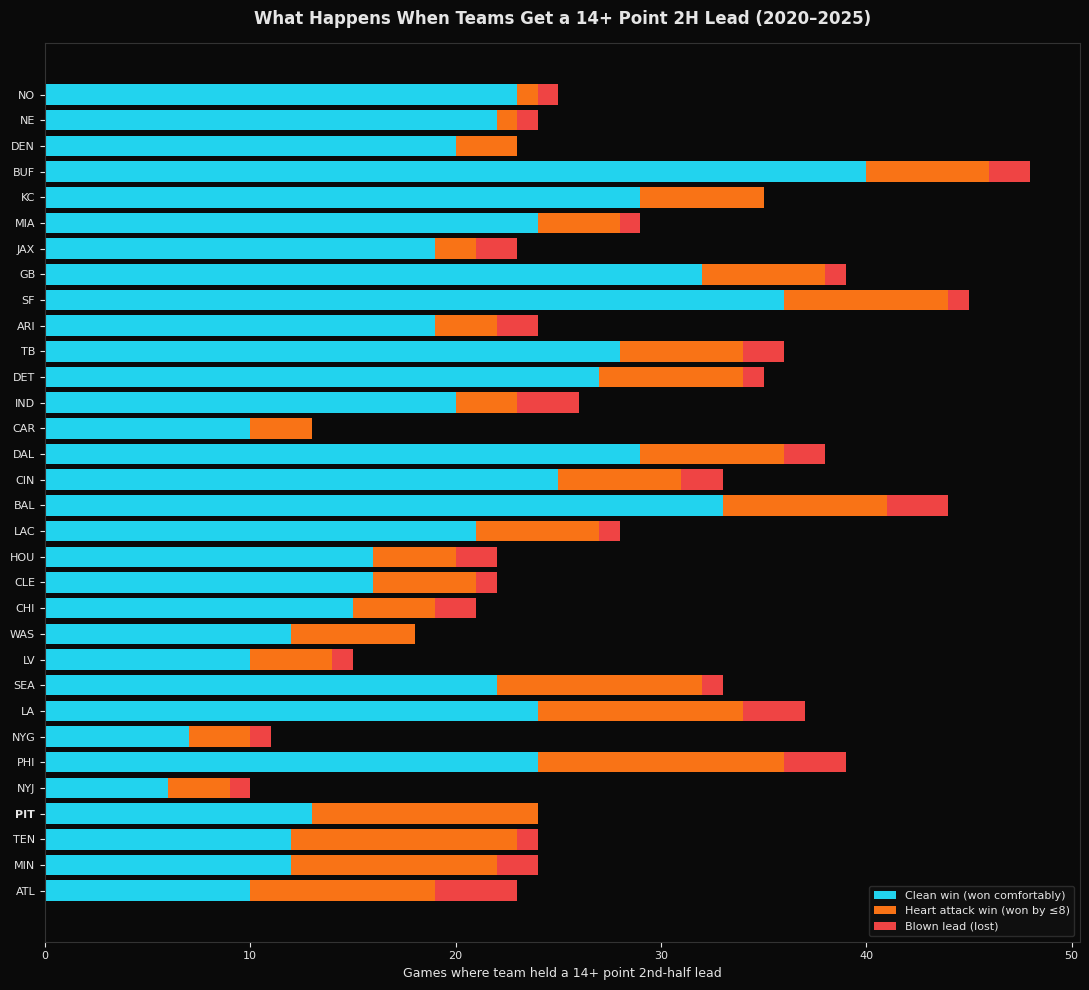

Saved lead-outcomes.png


In [21]:
# Stacked bar chart: for each team, of their big-lead games, split into:
# clean wins / heart attack wins / blown leads
# Sort by squander_rate descending
bl_chart = blown_stats.merge(
    games_with_leads2.groupby('team').agg(clean_wins=('had_big_lead', 'sum')).reset_index(),
    on='team'
)
# clean wins = big lead games - heart attack wins - blown leads
bl_chart['clean_wins'] = bl_chart['games_with_big_lead'] - bl_chart['heart_attack_wins'] - bl_chart['blown_leads']
bl_chart = bl_chart.sort_values('squander_rate', ascending=False)

fig, ax = plt.subplots(figsize=(11, 10), facecolor=BG)
ax.set_facecolor(BG)

teams = bl_chart['team'].tolist()
clean = bl_chart['clean_wins'].tolist()
ha    = bl_chart['heart_attack_wins'].tolist()
blown = bl_chart['blown_leads'].tolist()

bars1 = ax.barh(teams, clean, color='#22d3ee', label='Clean win (won comfortably)')
bars2 = ax.barh(teams, ha,    left=clean, color=ACCENT, label='Heart attack win (won by ≤8)')
bars3 = ax.barh(teams, blown, left=[c+h for c,h in zip(clean,ha)], color=RED, label='Blown lead (lost)')

# Highlight PIT tick label
for tick in ax.get_yticklabels():
    if tick.get_text() == 'PIT':
        tick.set_color(ACCENT)
        tick.set_fontweight('bold')

ax.set_xlabel("Games where team held a 14+ point 2nd-half lead", color=FG, fontsize=9)
ax.set_title("What Happens When Teams Get a 14+ Point 2H Lead (2020–2025)", color=FG, fontsize=12, fontweight='bold', pad=14)
ax.tick_params(colors=FG, labelsize=8)
for spine in ax.spines.values():
    spine.set_edgecolor("#333333")

ax.legend(facecolor='#111111', edgecolor='#333333', labelcolor=FG, fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'lead-outcomes.png'), dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Saved lead-outcomes.png")